In [1]:
"""Segmentation by text query with DINO and SAM."""

import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

import cv2
import torch
from segment_anything import sam_model_registry, SamPredictor

In [2]:
warnings.filterwarnings("ignore")

from groundingdino.util.box_ops import box_cxcywh_to_xyxy
from groundingdino.util.inference import load_model, load_image, predict

In [3]:
IMG_DIR = "../../data/evaluate/pics"

MODEL_DIR = "../../models/segmentation/text"
DETECTION_MODEL_CONFIG_PATH = "GroundingDINO_SwinT_OGC.py"
DETECTION_MODEL_WEIGHTS_PATH = "groundingdino_swint_ogc.pth"
SEGMENTATION_MODEL_TYPE = "vit_b"
SEGMENTATION_MODEL_PATH = "sam_vit_b_01ec64.pth"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
class TextSementator:
    def __init__(
        self,
        detection_config_path: str,
        detection_weights_path: str,
        segmentation_path: str,
        segmentation_type: str,
    ):
        # object detection
        self.dino = load_model(
            detection_config_path,
            detection_weights_path,
        )
        # segmentation
        sam = sam_model_registry[segmentation_type](segmentation_path)
        sam.to(device=DEVICE)

        self.predictor = SamPredictor(sam)

    def calc_masks(
        self,
        query: str,
        image_source: np.ndarray,
        image_transformed: torch.Tensor,
        box_threshold: float = 0.3,
        text_threshold: float = 0.3,
    ) -> np.ndarray:
        boxes, logits, phrases = predict(
            model=self.dino,
            image=image_transformed,
            caption=query,
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            device=DEVICE,
        )
        masks = []
        if len(boxes) > 0:
            h, w = image_source.shape[:2]

            boxes = boxes * torch.tensor([w, h, w, h], device=boxes.device)
            boxes = box_cxcywh_to_xyxy(boxes)

            boxes_xyxy = boxes.cpu().numpy()

            image_rgb = cv2.cvtColor(image_source, cv2.COLOR_BGR2RGB)
            self.predictor.set_image(image_rgb)

            for box in boxes_xyxy:
                mask, scores, _ = self.predictor.predict(
                    box=box,
                    multimask_output=False,
                )
                masks.append(mask[0])

        return np.array(masks)

In [5]:
segmentator = TextSementator(
    os.path.join(MODEL_DIR, DETECTION_MODEL_CONFIG_PATH),
    os.path.join(MODEL_DIR, DETECTION_MODEL_WEIGHTS_PATH),
    os.path.join(MODEL_DIR, SEGMENTATION_MODEL_PATH),
    SEGMENTATION_MODEL_TYPE,
)

final text_encoder_type: bert-base-uncased


In [6]:
class PlotStyle:
    width: int = 5
    height: int = 5
    point_color: str = "red"
    point_size: int = 40
    segment_alpha: float = 0.4


style = PlotStyle()

In [7]:
def find_segment(query: str, fn: str, topn: int = 3, mask_alpha: float = 0.5) -> None:
    image_source, image_transformed = load_image(os.path.join(IMG_DIR, fn))
    masks = segmentator.calc_masks(query, image_source, image_transformed)

    fig, axes = plt.subplots(1, 1, figsize=(style.width, style.height))
    fig.patch.set_visible(False)
    axes.axis("off")

    axes.imshow(cv2.cvtColor(image_source, cv2.COLOR_BGR2RGB))

    if len(masks) > 0:
        combined_mask = np.zeros_like(masks[0], dtype=bool)
        for mask in masks[:topn]:
            combined_mask = np.logical_or(combined_mask, mask)

        axes.imshow(combined_mask, alpha=mask_alpha)

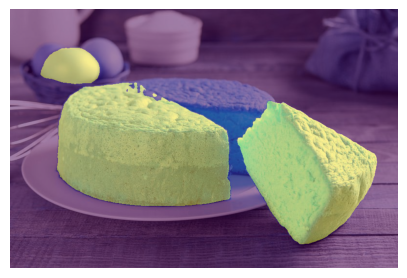

In [8]:
find_segment("food", "1.jpg")

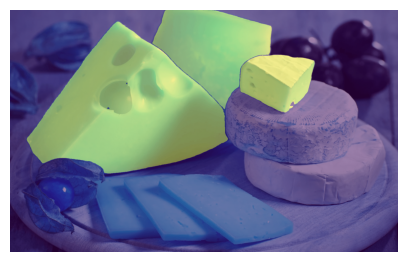

In [9]:
find_segment("food", "3.jpg")

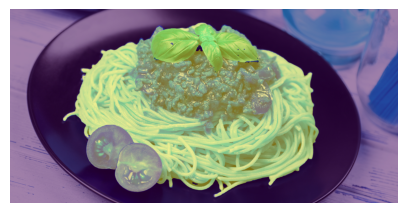

In [10]:
find_segment("food", "4.jpg")

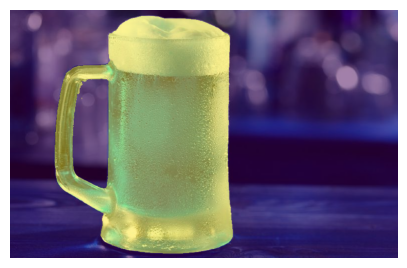

In [11]:
find_segment("food", "8.jpg")

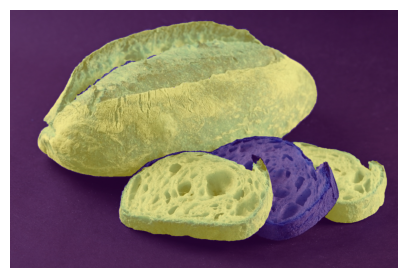

In [12]:
find_segment("food", "14.jpg")